# Gmsh Animation Export

This notebook is the small, result-saved teaching path for exporting a Gmsh animation from an existing `.geo` launch artifact. It opens `animation.geo`, lets Gmsh auto-load `animation.geo.opt`, synchronizes the visible view time steps, writes PNG frames through the Gmsh Python API, and encodes GIF/MP4 outputs.

The file roles are intentionally explicit:

- `animation.geo`: user-facing launch recipe; it merges the `.msh` data.
- `animation.geo.opt`: exact option sidecar auto-loaded when `animation.geo` opens.
- `rotor_animation.msh.opt`: raw mesh/data inspection sidecar when the `.msh` is opened directly.


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
NOTEBOOK_LABEL = Path('.')
if not (NOTEBOOK_DIR / 'gmsh_animation_export.py').exists():
    NOTEBOOK_DIR = Path('docs/gmsh_animation').resolve()
    NOTEBOOK_LABEL = Path('docs/gmsh_animation')
sys.path.insert(0, str(NOTEBOOK_DIR))

from gmsh_animation_export import (
    export_animation,
    write_results_json,
    format_summary,
)

print(f'notebook dir: {NOTEBOOK_LABEL.as_posix()}')

notebook dir: .


In [2]:
result = export_animation(
    NOTEBOOK_DIR,
    width=700,
    height=480,
    duration_ms=80,
)
json_path = write_results_json(
    result,
    NOTEBOOK_DIR / 'gmsh_animation_export_results.json',
)
print(format_summary(result))
print()
print(f'wrote {json_path.relative_to(NOTEBOOK_DIR)}')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (500, 480) to (512, 480) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


opened: docs/gmsh_animation/animation.geo
geo sidecar: docs/gmsh_animation/animation.geo.opt
raw msh sidecar: docs/gmsh_animation/rotor_animation.msh.opt
frames: 21
gif: docs/gmsh_animation/gmsh_animation_export.gif (244370 bytes)
mp4: docs/gmsh_animation/gmsh_animation_export.mp4 (100406 bytes)
checks: geo=True, geo_opt=True, gif=True, mp4=True

wrote gmsh_animation_export_results.json


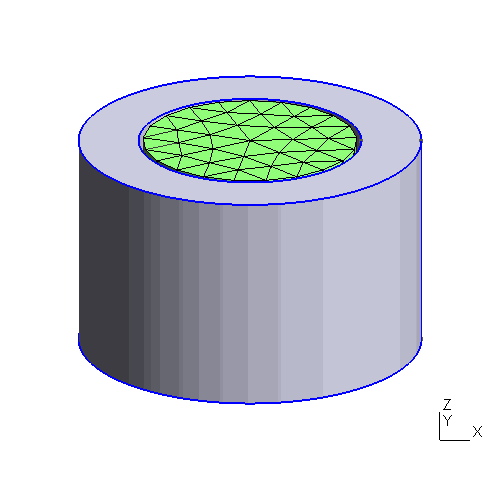

In [3]:
from IPython.display import Image, display

gif_path = NOTEBOOK_DIR / 'gmsh_animation_export.gif'
display(Image(filename=str(gif_path)))

In [4]:
roles = {
    'geo_launch': result['source']['geo']['path'],
    'geo_exact_opt': result['source']['geo_opt']['path'],
    'raw_msh_opt': result['source']['msh_opt']['path'],
    'gif': result['artifacts']['gif']['path'],
    'mp4': result['artifacts']['mp4']['path'],
}
for key, value in roles.items():
    print(f'{key}: {value}')

assert result['checks']['opened_geo_not_msh']
assert result['checks']['geo_opt_exact_sidecar']
assert result['checks']['msh_opt_raw_inspection_sidecar']
assert result['checks']['gif_written']
assert result['checks']['mp4_written']

geo_launch: docs/gmsh_animation/animation.geo
geo_exact_opt: docs/gmsh_animation/animation.geo.opt
raw_msh_opt: docs/gmsh_animation/rotor_animation.msh.opt
gif: docs/gmsh_animation/gmsh_animation_export.gif
mp4: docs/gmsh_animation/gmsh_animation_export.mp4
